In [221]:
import sys 
print(sys.executable)

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import xgboost as xgb
import streamlit as st 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score


import joblib


c:\Users\benja\AppData\Local\Programs\Python\Python312\python.exe


In [222]:
df = pd.read_excel('2019-2026.xlsx')

display(df)

,Donation Date (UTC),Intended Donation,Amount Charged,First Name,Last Name,Email,Address,City,State,Zipcode,Phone,Campaign,Comment
0,2019-03-14,100.0,100.00,Bruce,Boyea,noemail+59@123.com,NaN,NaN,NaN,NaN,NaN,NaN,"In Memory of Christopher Demtrak, MD"
1,2019-03-15,200.0,208.90,Lee Ann,Simonis,lsimonis@keyscomp.com,NaN,NaN,NaN,NaN,NaN,Captain & Crew Golf Tournament,NaN
2,2019-03-18,100.0,100.00,Paul & Nicole,Huff,noemail+206@123.com,NaN,NaN,NaN,NaN,NaN,NaN,In Memory of Christopher Demtrak
3,2019-04-06,100.0,104.60,Denise,Barry,dbarry3@partners.org,NaN,NaN,NaN,NaN,NaN,NaN,In Memory of Christopher Demtrak
4,2019-06-10,650.0,650.00,George,Scherer,gschere1@aol.com,9 Pamela Dr,Binghamton,New York,13901,607-648-8308,Captain & Crew Golf Tournament,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,2025-12-29,500.0,532.00,Leah,Cunningham,cunninghaml@me.com,NaN,NaN,NaN,13903,NaN,Boys & Girls Club of Binghamton Great Futures ...,In memory of Dr. Pejo
749,2025-12-29,100.0,106.65,Mark,Smith,smith.mark.hc13@gmail.com,NaN,NaN,NaN,13905,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN
750,2025-12-29,100.0,106.65,Marian,Avery,marian.avery@psbt.com,NaN,NaN,NaN,13905,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN
751,2025-12-31,250.0,266.16,R J,Mirabito Jr,richard.mirabito@gmail.com,NaN,NaN,NaN,75205,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN


In [223]:
#change names so they are easier to work with

df.columns = df.columns.str.lower()

display(df)


    


,donation date (utc),intended donation,amount charged,first name,last name,email,address,city,state,zipcode,phone,campaign,comment
0,2019-03-14,100.0,100.00,Bruce,Boyea,noemail+59@123.com,NaN,NaN,NaN,NaN,NaN,NaN,"In Memory of Christopher Demtrak, MD"
1,2019-03-15,200.0,208.90,Lee Ann,Simonis,lsimonis@keyscomp.com,NaN,NaN,NaN,NaN,NaN,Captain & Crew Golf Tournament,NaN
2,2019-03-18,100.0,100.00,Paul & Nicole,Huff,noemail+206@123.com,NaN,NaN,NaN,NaN,NaN,NaN,In Memory of Christopher Demtrak
3,2019-04-06,100.0,104.60,Denise,Barry,dbarry3@partners.org,NaN,NaN,NaN,NaN,NaN,NaN,In Memory of Christopher Demtrak
4,2019-06-10,650.0,650.00,George,Scherer,gschere1@aol.com,9 Pamela Dr,Binghamton,New York,13901,607-648-8308,Captain & Crew Golf Tournament,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,2025-12-29,500.0,532.00,Leah,Cunningham,cunninghaml@me.com,NaN,NaN,NaN,13903,NaN,Boys & Girls Club of Binghamton Great Futures ...,In memory of Dr. Pejo
749,2025-12-29,100.0,106.65,Mark,Smith,smith.mark.hc13@gmail.com,NaN,NaN,NaN,13905,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN
750,2025-12-29,100.0,106.65,Marian,Avery,marian.avery@psbt.com,NaN,NaN,NaN,13905,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN
751,2025-12-31,250.0,266.16,R J,Mirabito Jr,richard.mirabito@gmail.com,NaN,NaN,NaN,75205,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN


In [224]:
#Create for loop to iterate over items and identify number of missing values in each column: 

print("Missing Values:")
for col_name in df.columns:
    print(f"{col_name}: {df[col_name].isna().sum()}")  
print("--End Missing Values------\n")
    


print("----UNIQUE VALUES----")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")
print("-----END UNIQUE-------")




Missing Values:
donation date (utc): 0
intended donation: 0
amount charged: 0
first name: 0
last name: 78
email: 352
address: 731
city: 727
state: 727
zipcode: 691
phone: 748
campaign: 168
comment: 680
--End Missing Values------

----UNIQUE VALUES----
donation date (utc): 388
intended donation: 42
amount charged: 68
first name: 383
last name: 312
email: 215
address: 22
city: 14
state: 3
zipcode: 28
phone: 5
campaign: 10
comment: 64
-----END UNIQUE-------


Feature Engineering- We will create a feature that includes 1. Comment length (a zero value will indicate no comment was left)  2. A payment that was likely made with a credit card 3. Those who attended an event. & 4. OHE Campaign Column 

Create a Histogram Chart to Visualize the distribution of the different Campaigns.  The frequency could impact our modeling, and potentially, a more equalized distribution could result a more accurate prediction model.  

amount charged         0
campaign               0
comment_word_length    0
likely_cc              0
year                   0
month                  0
day                    0
day_of_week            0
dtype: int64

,amount charged,campaign,comment_word_length,likely_cc,year,month,day,day_of_week
0,208.90,Captain & Crew Golf Tournament,0,1,2019,3,15,4
1,650.00,Captain & Crew Golf Tournament,0,0,2019,6,10,0
2,200.00,Captain & Crew Golf Tournament,0,0,2019,6,13,3
3,75.00,Great Futures 2019 - Whatever It Takes,0,0,2019,9,23,0
4,150.00,Great Futures 2019 - Whatever It Takes,0,0,2019,9,23,0
...,...,...,...,...,...,...,...,...
580,266.16,Boys & Girls Club of Binghamton Great Futures ...,0,1,2025,12,23,1
581,532.00,Boys & Girls Club of Binghamton Great Futures ...,5,1,2025,12,29,0
582,106.65,Boys & Girls Club of Binghamton Great Futures ...,0,1,2025,12,29,0
583,106.65,Boys & Girls Club of Binghamton Great Futures ...,0,1,2025,12,29,0


amount charged         float64
campaign                   str
comment_word_length      int64
likely_cc                int64
year                     int32
month                    int32
day                      int32
day_of_week              int32
dtype: object

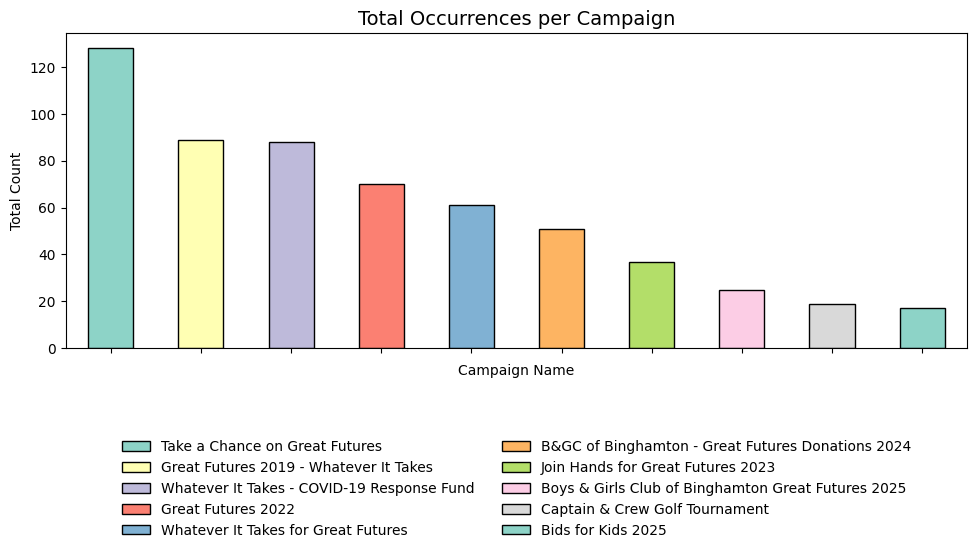

,amount charged,comment_word_length,likely_cc,year,month,day,day_of_week,campaign_Bids for Kids 2025,campaign_Boys & Girls Club of Binghamton Great Futures 2025,campaign_Captain & Crew Golf Tournament,campaign_Great Futures 2019 - Whatever It Takes,campaign_Great Futures 2022,campaign_Join Hands for Great Futures 2023,campaign_Take a Chance on Great Futures,campaign_Whatever It Takes - COVID-19 Response Fund,campaign_Whatever It Takes for Great Futures
0,208.90,0,1,2019,3,15,4,0,0,1,0,0,0,0,0,0
1,650.00,0,0,2019,6,10,0,0,0,1,0,0,0,0,0,0
2,200.00,0,0,2019,6,13,3,0,0,1,0,0,0,0,0,0
3,75.00,0,0,2019,9,23,0,0,0,0,1,0,0,0,0,0
4,150.00,0,0,2019,9,23,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,266.16,0,1,2025,12,23,1,0,1,0,0,0,0,0,0,0
581,532.00,5,1,2025,12,29,0,0,1,0,0,0,0,0,0,0
582,106.65,0,1,2025,12,29,0,0,1,0,0,0,0,0,0,0
583,106.65,0,1,2025,12,29,0,0,1,0,0,0,0,0,0,0


amount charged                                                 0
comment_word_length                                            0
likely_cc                                                      0
year                                                           0
month                                                          0
day                                                            0
day_of_week                                                    0
campaign_Bids for Kids 2025                                    0
campaign_Boys & Girls Club of Binghamton Great Futures 2025    0
campaign_Captain & Crew Golf Tournament                        0
campaign_Great Futures 2019 - Whatever It Takes                0
campaign_Great Futures 2022                                    0
campaign_Join Hands for Great Futures 2023                     0
campaign_Take a Chance on Great Futures                        0
campaign_Whatever It Takes - COVID-19 Response Fund            0
campaign_Whatever It Take

In [225]:
#Create comment length feature 
df['comment_word_length'] = df['comment'].fillna('').str.split().str.len()

#Create Likely Credit Card Feature
df['fee'] = df['amount charged'] - df['intended donation']
df['fee perc'] = df['fee'] / df['intended donation']
df['fee_pct'] = np.where(
    df['intended donation'] > 0,
    df['fee'] / df['intended donation'],
    0
)

#Credit Card Fees are typically 2-7%, so flag for fees in that range 
df['likely_cc'] = (df['fee_pct'].between(0.02, 0.07)).astype(int)

#Convert donation date (utc) to ML- useful values 
df["donation date (utc)"] = pd.to_datetime(df["donation date (utc)"])
df["year"] = df["donation date (utc)"].dt.year
df["month"] = df["donation date (utc)"].dt.month
df["day"] = df["donation date (utc)"].dt.day
df["day_of_week"] = df["donation date (utc)"].dt.dayofweek

#Drop Columns, null values
df.drop(columns=['first name', 'last name', 'email', 'address', 'city', 'state', 'phone', 'fee', 'fee_pct', 'fee perc','comment', 'donation date (utc)', 'zipcode', 'intended donation'], inplace=True)

#Drop Duplicates
df_ohe = df.drop_duplicates()
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
display(df.isna().sum())
display(df)
display(df.dtypes)
df.describe()

#Visualize Bar Chart of Campaigns

campaign_counts = df['campaign'].value_counts()
colors = plt.cm.Set3(range(9)) 

plot1 = campaign_counts.plot(kind='bar', color=colors, edgecolor='black', figsize=(10, 6))
plt.title('Total Occurrences per Campaign', fontsize=14)
plt.ylabel('Total Count')
plt.xlabel('Campaign Name')
plot1.set_xticklabels([])

plt.legend(plot1.patches, campaign_counts.index, loc='upper center', 
           bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)

plt.tight_layout()
plt.show()



#OHE Campaign & Zipcode Columns
df_ohe = pd.get_dummies(df , columns=['campaign'], drop_first=True, dtype=int)



#Double check to ensure that there are no missing values in df_ohe before splitting
display(df_ohe)
display(df_ohe.isna().sum())

Machine Learning Model:  Start out by testing the model to predict if there will be a high donation.  



In [226]:

X = df_ohe.drop("amount charged", axis = 1)
y = df_ohe['amount charged']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

model = RandomForestRegressor(
  n_estimators=200,
  max_depth = 3,
  random_state=42
)

model.fit(X_train,y_train)

#Prediction
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(r2)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)


(468, 15)
(117, 15)
0.05102275528956435
campaign_Take a Chance on Great Futures                        0.430880
day                                                            0.275648
year                                                           0.078242
campaign_Captain & Crew Golf Tournament                        0.055510
likely_cc                                                      0.055287
day_of_week                                                    0.040676
month                                                          0.033506
comment_word_length                                            0.016065
campaign_Great Futures 2022                                    0.012912
campaign_Great Futures 2019 - Whatever It Takes                0.000687
campaign_Bids for Kids 2025                                    0.000441
campaign_Whatever It Takes for Great Futures                   0.000146
campaign_Boys & Girls Club of Binghamton Great Futures 2025    0.000001
campaign_Join Hands for 

In [227]:
#Try XGBoost

model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 5) Predict + evaluate
pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)




R2: -0.4648086075049136
RMSE: 505.3731120313263
MAE: 311.3482383338406


In [228]:

#Create Binary Donation Column 
df_ohe['high donation'] = np.where(
  df_ohe['amount charged'] >= 500,
  1,
  0
)

X = df_ohe.drop(['amount charged','high donation'], axis=1)
y = df_ohe['high donation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestClassifier(n_estimators=500, 
      random_state=42,
      class_weight="balanced"
      )

model.fit(X_train, y_train)

pred = model.predict(X_test)
print(df_ohe["high donation"].value_counts())


print('Random Forest Classifier: \n', classification_report(y_test, pred))



#Logistic Regression 
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
print('Logistic Regression Accuracy: \n', classification_report(y_test, pred))


y_prob = model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)


print('\n ROC_AUC Score:', roc_auc)



high donation
0    454
1    131
Name: count, dtype: int64
Random Forest Classifier: 
               precision    recall  f1-score   support

           0       0.78      0.76      0.77        85
           1       0.41      0.44      0.42        32

    accuracy                           0.68       117
   macro avg       0.60      0.60      0.60       117
weighted avg       0.68      0.68      0.68       117

Logistic Regression Accuracy: 
               precision    recall  f1-score   support

           0       0.81      0.71      0.75        85
           1       0.42      0.56      0.48        32

    accuracy                           0.67       117
   macro avg       0.61      0.63      0.62       117
weighted avg       0.70      0.67      0.68       117


 ROC_AUC Score: 0.6696691176470588


While the accuracy score of the random classifier is high in this case, it is also misleading.  0's comprise approximately 76% of the dataset which is actually close to the 72% accuracy score using this model.  Looking closer at the Classification Report, we are able to see that recall is much higher for 0 than 1, indicating that model training is skewed towards identifying those who would not be donors.  

The Logisitic Regression Model, while less accurate, paints a better picture as evidenced by a more equally distributed recall. 

In [229]:
#Serialization:  Package Model into Byte Stream via joblib

print(X_train.columns.tolist())

joblib.dump(model, "donation-model.pkl")
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

model = joblib.load("donation-model.pkl")
model_columns = joblib.load("model_columns.pkl")


print(X_test.iloc[[20]])
print(y_test.iloc[[20]])
sample = X_test.iloc[[20]]

model.predict(sample)
model.predict_proba(sample)








['comment_word_length', 'likely_cc', 'year', 'month', 'day', 'day_of_week', 'campaign_Bids for Kids 2025', 'campaign_Boys & Girls Club of Binghamton Great Futures 2025', 'campaign_Captain & Crew Golf Tournament ', 'campaign_Great Futures 2019 - Whatever It Takes', 'campaign_Great Futures 2022', 'campaign_Join Hands for Great Futures 2023', 'campaign_Take a Chance on Great Futures ', 'campaign_Whatever It Takes - COVID-19 Response Fund', 'campaign_Whatever It Takes for Great Futures ']
     comment_word_length  likely_cc  year  month  day  day_of_week  \
355                    0          0  2022      1    4            1   

     campaign_Bids for Kids 2025  \
355                            0   

     campaign_Boys & Girls Club of Binghamton Great Futures 2025  \
355                                                  0             

     campaign_Captain & Crew Golf Tournament   \
355                                         0   

     campaign_Great Futures 2019 - Whatever It Takes  \
355 

array([[0.70064941, 0.29935059]])

In [230]:
#obtain unique campaign values for model using list comprehension

campaign_cols = [col for col in df_ohe.columns if col.startswith("campaign_")]
print(campaign_cols)




['campaign_Bids for Kids 2025', 'campaign_Boys & Girls Club of Binghamton Great Futures 2025', 'campaign_Captain & Crew Golf Tournament ', 'campaign_Great Futures 2019 - Whatever It Takes', 'campaign_Great Futures 2022', 'campaign_Join Hands for Great Futures 2023', 'campaign_Take a Chance on Great Futures ', 'campaign_Whatever It Takes - COVID-19 Response Fund', 'campaign_Whatever It Takes for Great Futures ']


Deployment of Model to Streamlit

In [231]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load saved model artifacts
model = joblib.load("donation-model.pkl")
model_columns = joblib.load("model_columns.pkl")

# Build campaign dropdown from model columns
campaign_cols = [c for c in model_columns if c.startswith("campaign_")]


st.title("Donor Prediction Model")
st.write("Enter the info below to determine if the person will be a high or low donor")

#Dropdown box for campaign values obtained from OHE campaign column values to match up with deployed model

campaign_options = [col.replace("campaign_", "") for col in campaign_cols]



#User inputs 

comment = st.text_area("Comment")
credit_card = st.selectbox("Was a credit card used?", ["No", "Yes"])
campaign = st.selectbox("Campaign", campaign_options)
donation_date = st.date_input("Donation Date")


#Create Preprocessing function that can run in the app 

def preprocess_df(comment, credit_card, campaign, donation_date):
    comment_word_length = len(str(comment).split()) if comment else 0
    likely_cc = 1 if credit_card == "Yes" else 0

    donation_date = pd.to_datetime(donation_date)
    year = donation_date.year
    month = donation_date.month
    day = donation_date.day
    day_of_week = donation_date.dayofweek

    # Create one-row dataframe with all model columns set to 0
    processed = pd.DataFrame(0, index=[0], columns=model_columns)

    # Fill numeric features
    processed.at[0, "likely_cc"] = likely_cc
    processed.at[0, "day"] = day
    processed.at[0, "year"] = year
    processed.at[0, "day_of_week"] = day_of_week
    processed.at[0, "month"] = month
    processed.at[0, "comment_word_length"] = comment_word_length

    # Turn on selected campaign column (set to 1)
    campaign_col = f"campaign_{campaign}"
    if campaign_col in processed.columns:
        processed.at[0, campaign_col] = 1

    return processed


if st.button("Predict"):
    processed_input = preprocess_df(
        comment,
        credit_card,
        campaign,
        donation_date
    )

    prediction = model.predict(processed_input)[0]
    probability = model.predict_proba(processed_input)[0][1]

    if prediction == 1:
        st.success("Yes")
    else:
        st.error("No")

    st.write(f"Probability of high donation: {probability:.2%}")

Overwriting app.py


The plot above shows that the incidence of NY is much, much higher than the other states, with AZ a far second.  All of the other states will be heavily under represented if we use the data as is.  Techniques such as OHE will be needed in addition to upsampling to enhance the frequency of under represented states.  

Looking at the scatter and histogram plots that we have created, it seems like there has been a decrease from the peak of donations at 2021.  This could perhaps be correlated to processes that have been discontinued/occurred only during 2021.  Perhaps this coincides with a significant event such as COVID for some reason.  Another insight retreived from these data is that the relative quantity of donations seems to peak around the end of the year.  